In [2]:
import pandas as pd
print(pd.__version__)


2.2.3


In [3]:
df = pd.read_csv('FWI Dataset.csv')
df.head(10)  # Shows first 10 rows

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire
5,06,06,2012,31,67,14,0,82.6,5.8,22.2,3.1,7,2.5,fire
6,07,06,2012,33,54,13,0,88.2,9.9,30.5,6.4,10.9,7.2,fire
7,08,06,2012,30,73,15,0,86.6,12.1,38.3,5.6,13.5,7.1,fire
8,09,06,2012,25,88,13,0.2,52.9,7.9,38.8,0.4,10.5,0.3,not fire
9,10,06,2012,28,79,12,0,73.2,9.5,46.3,1.3,12.6,0.9,not fire


In [4]:
df.shape

(246, 14)

In [5]:
df.info()       # Column names, types, non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.0+ KB


In [6]:
#Stripping the columns names to remove the extra spaces
df.columns = df.columns.str.strip()

In [7]:
# 1. Drop rows 124 to 126 by position
df = df.drop(df.index[123:126])

# 2. Reset index so it’s clean
df = df.reset_index(drop=True)

# 3. Create new region column
df['region'] = ['Bejaia'] * 122 + ['Sidi-Bel Abbes'] * (len(df) - 122)

print(df.head())   # check start
print(df.tail())   # check end


  day month  year Temperature  RH  Ws  Rain  FFMC  DMC    DC  ISI  BUI  FWI  \
0  01    06  2012          29  57  18     0  65.7  3.4   7.6  1.3  3.4  0.5   
1  02    06  2012          29  61  13   1.3  64.4  4.1   7.6    1  3.9  0.4   
2  03    06  2012          26  82  22  13.1  47.1  2.5   7.1  0.3  2.7  0.1   
3  04    06  2012          25  89  13   2.5  28.6  1.3   6.9    0  1.7    0   
4  05    06  2012          27  77  16     0  64.8    3  14.2  1.2  3.9  0.5   

       Classes  region  
0  not fire     Bejaia  
1  not fire     Bejaia  
2  not fire     Bejaia  
3  not fire     Bejaia  
4  not fire     Bejaia  
    day month  year Temperature  RH  Ws Rain  FFMC  DMC    DC  ISI   BUI  FWI  \
238  26    09  2012          30  65  14    0  85.4   16  44.5  4.5  16.9  6.5   
239  27    09  2012          28  87  15  4.4  41.1  6.5     8  0.1   6.2    0   
240  28    09  2012          27  87  29  0.5  45.9  3.5   7.9  0.4   3.4  0.2   
241  29    09  2012          24  54  18  0.1  79.7 

In [8]:
df.shape

(243, 15)

In [9]:
df.info()  #region column was added

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          243 non-null    object
 1   month        242 non-null    object
 2   year         242 non-null    object
 3   Temperature  242 non-null    object
 4   RH           242 non-null    object
 5   Ws           242 non-null    object
 6   Rain         242 non-null    object
 7   FFMC         242 non-null    object
 8   DMC          242 non-null    object
 9   DC           242 non-null    object
 10  ISI          242 non-null    object
 11  BUI          242 non-null    object
 12  FWI          242 non-null    object
 13  Classes      241 non-null    object
 14  region       243 non-null    object
dtypes: object(15)
memory usage: 28.6+ KB


In [10]:
print(df.columns.tolist()) #to see columns

['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'region']


In [11]:
df[df.isnull().any(axis=1)] #check missing value

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sidi-Bel Abbes
164,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN,Sidi-Bel Abbes


In [12]:
df.describe()   # Summary statistics (mean, min, max, std)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
count,243,242,242,242,242,242,242,242,242,242,242,242,242,241,243
unique,32,4,1,19,62,18,38,172,165,198,106,174,127,8,2
top,04,07,2012,35,64,14,0,88.9,7.9,8,1.1,3,0.4,fire,Bejaia
freq,8,62,242,29,10,43,133,8,5,5,8,5,12,131,122


In [13]:
df.isnull().sum() #for missing values


day            0
month          1
year           1
Temperature    1
RH             1
Ws             1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
region         0
dtype: int64

In [14]:
df = df.dropna()  # removes all rows that contain at least one missing value

In [15]:
df.duplicated().sum()    #Returns a new DataFrame without duplicates(keeps frst occurrnce of each row)
df = df.drop_duplicates()


In [16]:
df.describe(include='all') #gives one short summary of dataset including both numbers and categories.

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
count,241,241,241,241,241,241,241,241,241,241,241,241,241,241,241
unique,31,4,1,19,62,18,38,172,164,197,106,173,126,8,2
top,03,08,2012,35,64,14,0,88.9,7.9,8,1.1,3,0.4,fire,Bejaia
freq,8,62,241,29,10,43,133,7,5,5,8,5,12,131,122


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 241 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          241 non-null    object
 1   month        241 non-null    object
 2   year         241 non-null    object
 3   Temperature  241 non-null    object
 4   RH           241 non-null    object
 5   Ws           241 non-null    object
 6   Rain         241 non-null    object
 7   FFMC         241 non-null    object
 8   DMC          241 non-null    object
 9   DC           241 non-null    object
 10  ISI          241 non-null    object
 11  BUI          241 non-null    object
 12  FWI          241 non-null    object
 13  Classes      241 non-null    object
 14  region       241 non-null    object
dtypes: object(15)
memory usage: 30.1+ KB


In [18]:
df.dropna()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,Bejaia
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,Bejaia
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,Bejaia
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,Bejaia
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,Bejaia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,26,09,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire,Sidi-Bel Abbes
239,27,09,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire,Sidi-Bel Abbes
240,28,09,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,Sidi-Bel Abbes
241,29,09,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,Sidi-Bel Abbes


In [19]:
# Convert DC and FWI to float
df["DC"] = pd.to_numeric(df["DC"], errors="coerce")
df["FWI"] = pd.to_numeric(df["FWI"], errors="coerce")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 241 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          241 non-null    object 
 1   month        241 non-null    object 
 2   year         241 non-null    object 
 3   Temperature  241 non-null    object 
 4   RH           241 non-null    object 
 5   Ws           241 non-null    object 
 6   Rain         241 non-null    object 
 7   FFMC         241 non-null    object 
 8   DMC          241 non-null    object 
 9   DC           241 non-null    float64
 10  ISI          241 non-null    object 
 11  BUI          241 non-null    object 
 12  FWI          241 non-null    float64
 13  Classes      241 non-null    object 
 14  region       241 non-null    object 
dtypes: float64(2), object(13)
memory usage: 30.1+ KB


In [20]:
print(df.columns.tolist()) #to see columns

['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'region']


In [21]:

# Remove leading/trailing spaces from all column names
#df.columns = df.columns.str.strip()

# Now your numeric columns should match correctly
numeric_cols = [
    'day', 'month', 'year',
    'Temperature', 'RH', 'Ws', 'Rain',
    'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI'
]

# Convert to numeric (coerce errors into NaN if any bad data)
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Optional: convert some to int if they are whole numbers
df['day'] = df['day'].astype(int)
df['month'] = df['month'].astype(int)
df['year'] = df['year'].astype(int)


print(df.dtypes)


day              int64
month            int64
year             int64
Temperature      int64
RH               int64
Ws               int64
Rain           float64
FFMC           float64
DMC            float64
DC             float64
ISI            float64
BUI            float64
FWI            float64
Classes         object
region          object
dtype: object


In [22]:
# Drop any remaining rows with NaNs
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 241 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          241 non-null    int64  
 1   month        241 non-null    int64  
 2   year         241 non-null    int64  
 3   Temperature  241 non-null    int64  
 4   RH           241 non-null    int64  
 5   Ws           241 non-null    int64  
 6   Rain         241 non-null    float64
 7   FFMC         241 non-null    float64
 8   DMC          241 non-null    float64
 9   DC           241 non-null    float64
 10  ISI          241 non-null    float64
 11  BUI          241 non-null    float64
 12  FWI          241 non-null    float64
 13  Classes      241 non-null    object 
 14  region       241 non-null    object 
dtypes: float64(7), int64(6), object(2)
memory usage: 30.1+ KB


In [23]:
# 1. Fix column names
df = df.rename(columns=lambda x: x.strip())

# 2. Impute missing values in 'Classes' with mode (can aslo done by median r specific value)
df['Classes'] = df['Classes'].fillna(df['Classes'].mode()[0])

# 3. Drop 'Classes' column
df = df.drop(columns=['Classes'])

print(df.head())


   day  month  year  Temperature  RH  Ws  Rain  FFMC  DMC    DC  ISI  BUI  \
0    1      6  2012           29  57  18   0.0  65.7  3.4   7.6  1.3  3.4   
1    2      6  2012           29  61  13   1.3  64.4  4.1   7.6  1.0  3.9   
2    3      6  2012           26  82  22  13.1  47.1  2.5   7.1  0.3  2.7   
3    4      6  2012           25  89  13   2.5  28.6  1.3   6.9  0.0  1.7   
4    5      6  2012           27  77  16   0.0  64.8  3.0  14.2  1.2  3.9   

   FWI  region  
0  0.5  Bejaia  
1  0.4  Bejaia  
2  0.1  Bejaia  
3  0.0  Bejaia  
4  0.5  Bejaia  


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 241 entries, 0 to 242
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          241 non-null    int64  
 1   month        241 non-null    int64  
 2   year         241 non-null    int64  
 3   Temperature  241 non-null    int64  
 4   RH           241 non-null    int64  
 5   Ws           241 non-null    int64  
 6   Rain         241 non-null    float64
 7   FFMC         241 non-null    float64
 8   DMC          241 non-null    float64
 9   DC           241 non-null    float64
 10  ISI          241 non-null    float64
 11  BUI          241 non-null    float64
 12  FWI          241 non-null    float64
 13  region       241 non-null    object 
dtypes: float64(7), int64(6), object(1)
memory usage: 28.2+ KB


In [25]:



# Verify
print("Columns after dropping:", df.columns.tolist())


Columns after dropping: ['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'region']


### MODULE-2:Data Exploration and Data Preprocessing

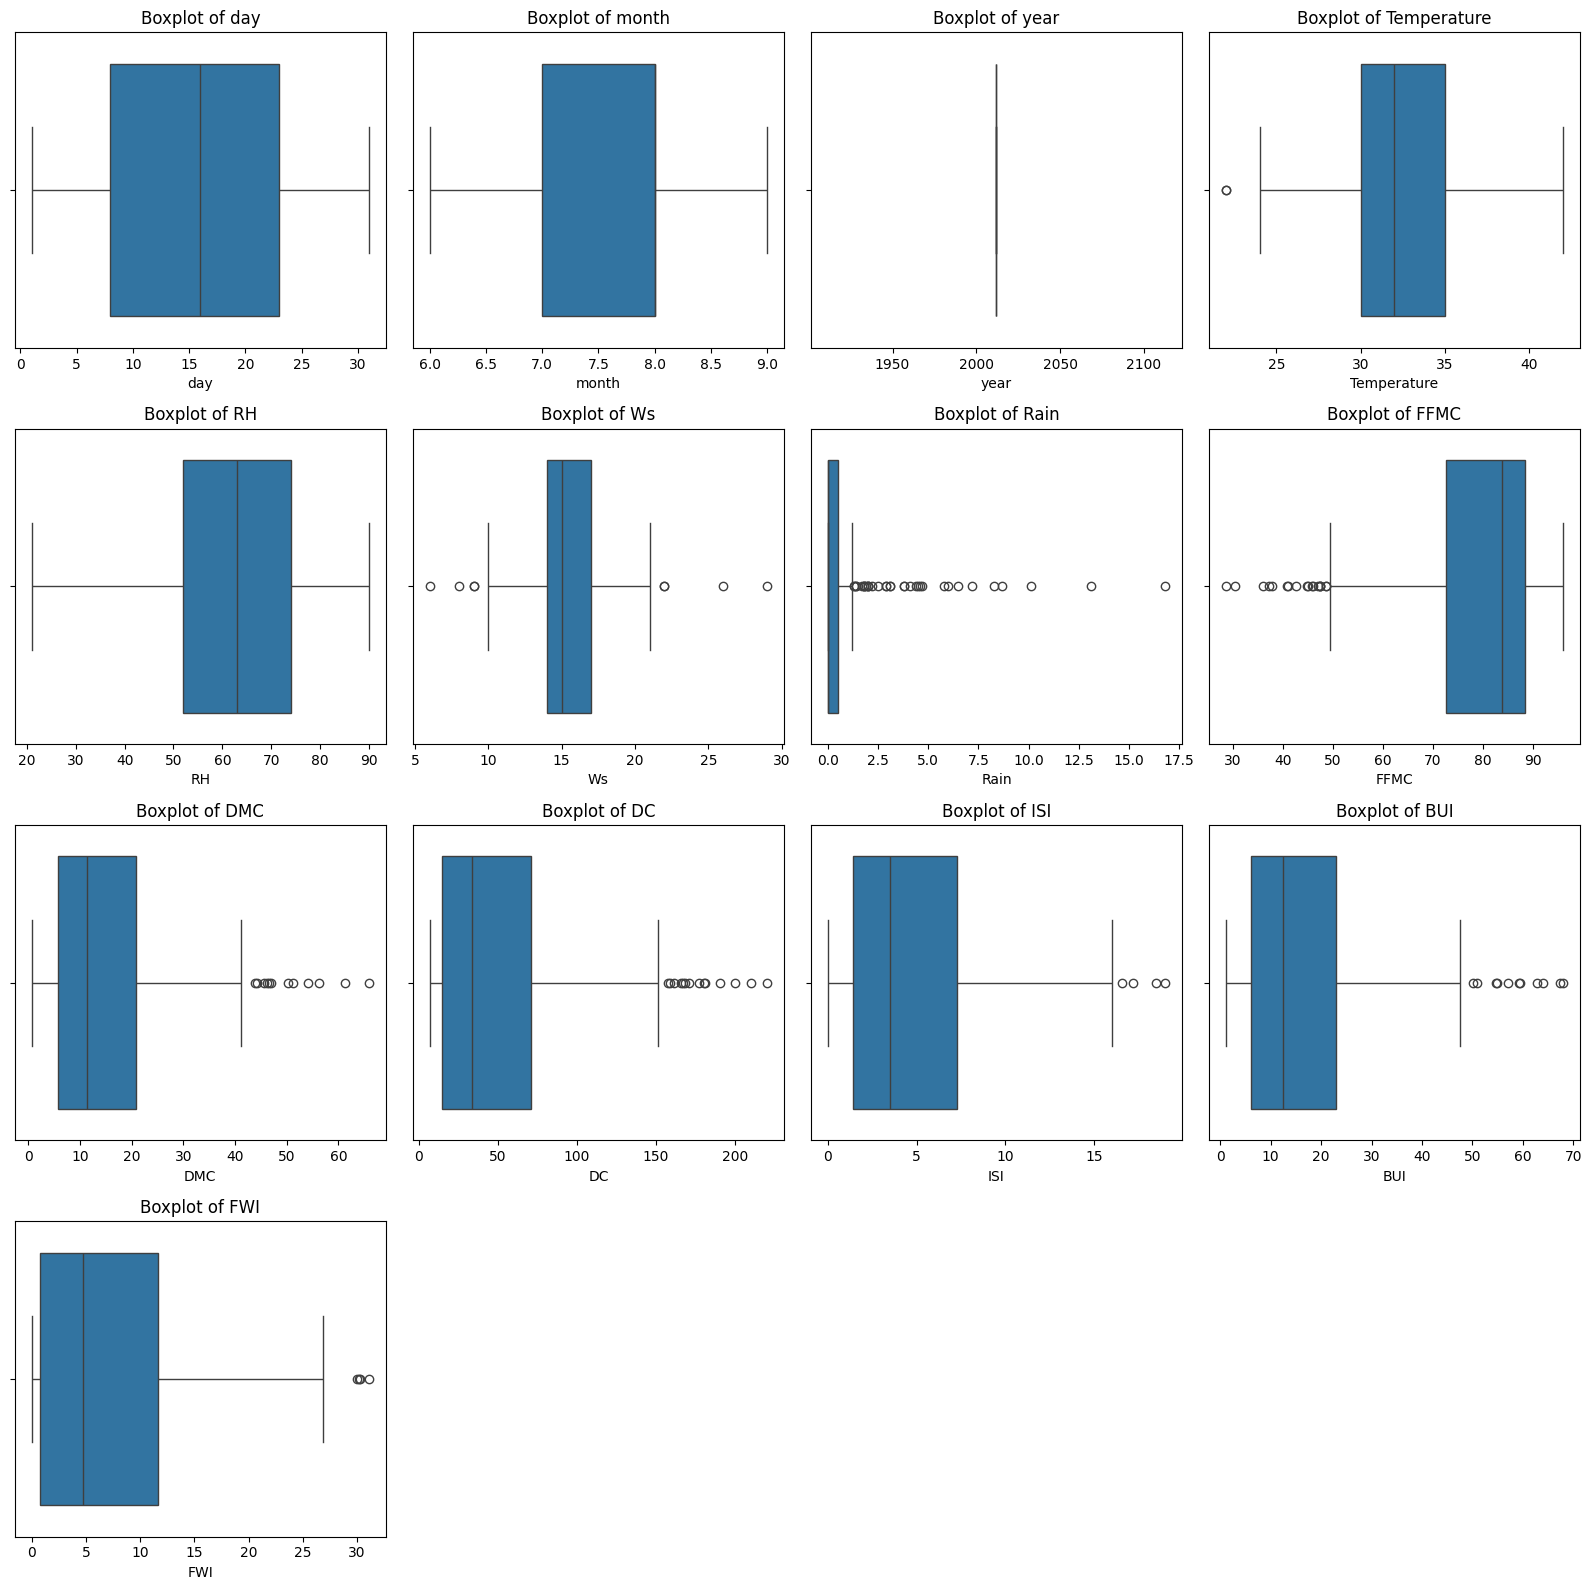

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numeric columns
numeric_cols = [
    'day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain',
    'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI'
]

# Define the number of rows and columns for subplots
n_cols = 4  # number of columns in subplot grid
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols  # auto calculate rows

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()  # flatten in case of multiple rows

# Plot boxplots
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')

# Remove empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [27]:
# Function to count outliers using IQR (IQR=above75% data-25% data)
def outlier_count(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

# Apply to all numeric columns
numeric_cols = [
    'day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain',
    'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI'
]

outlier_summary = {col: outlier_count(df[col]) for col in numeric_cols}

# Show results
import pandas as pd
outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Outlier Count'])
print(outlier_df)
#

             Outlier Count
day                      0
month                    0
year                     0
Temperature              2
RH                       0
Ws                       8
Rain                    34
FFMC                    18
DMC                     12
DC                      14
ISI                      4
BUI                     11
FWI                      4


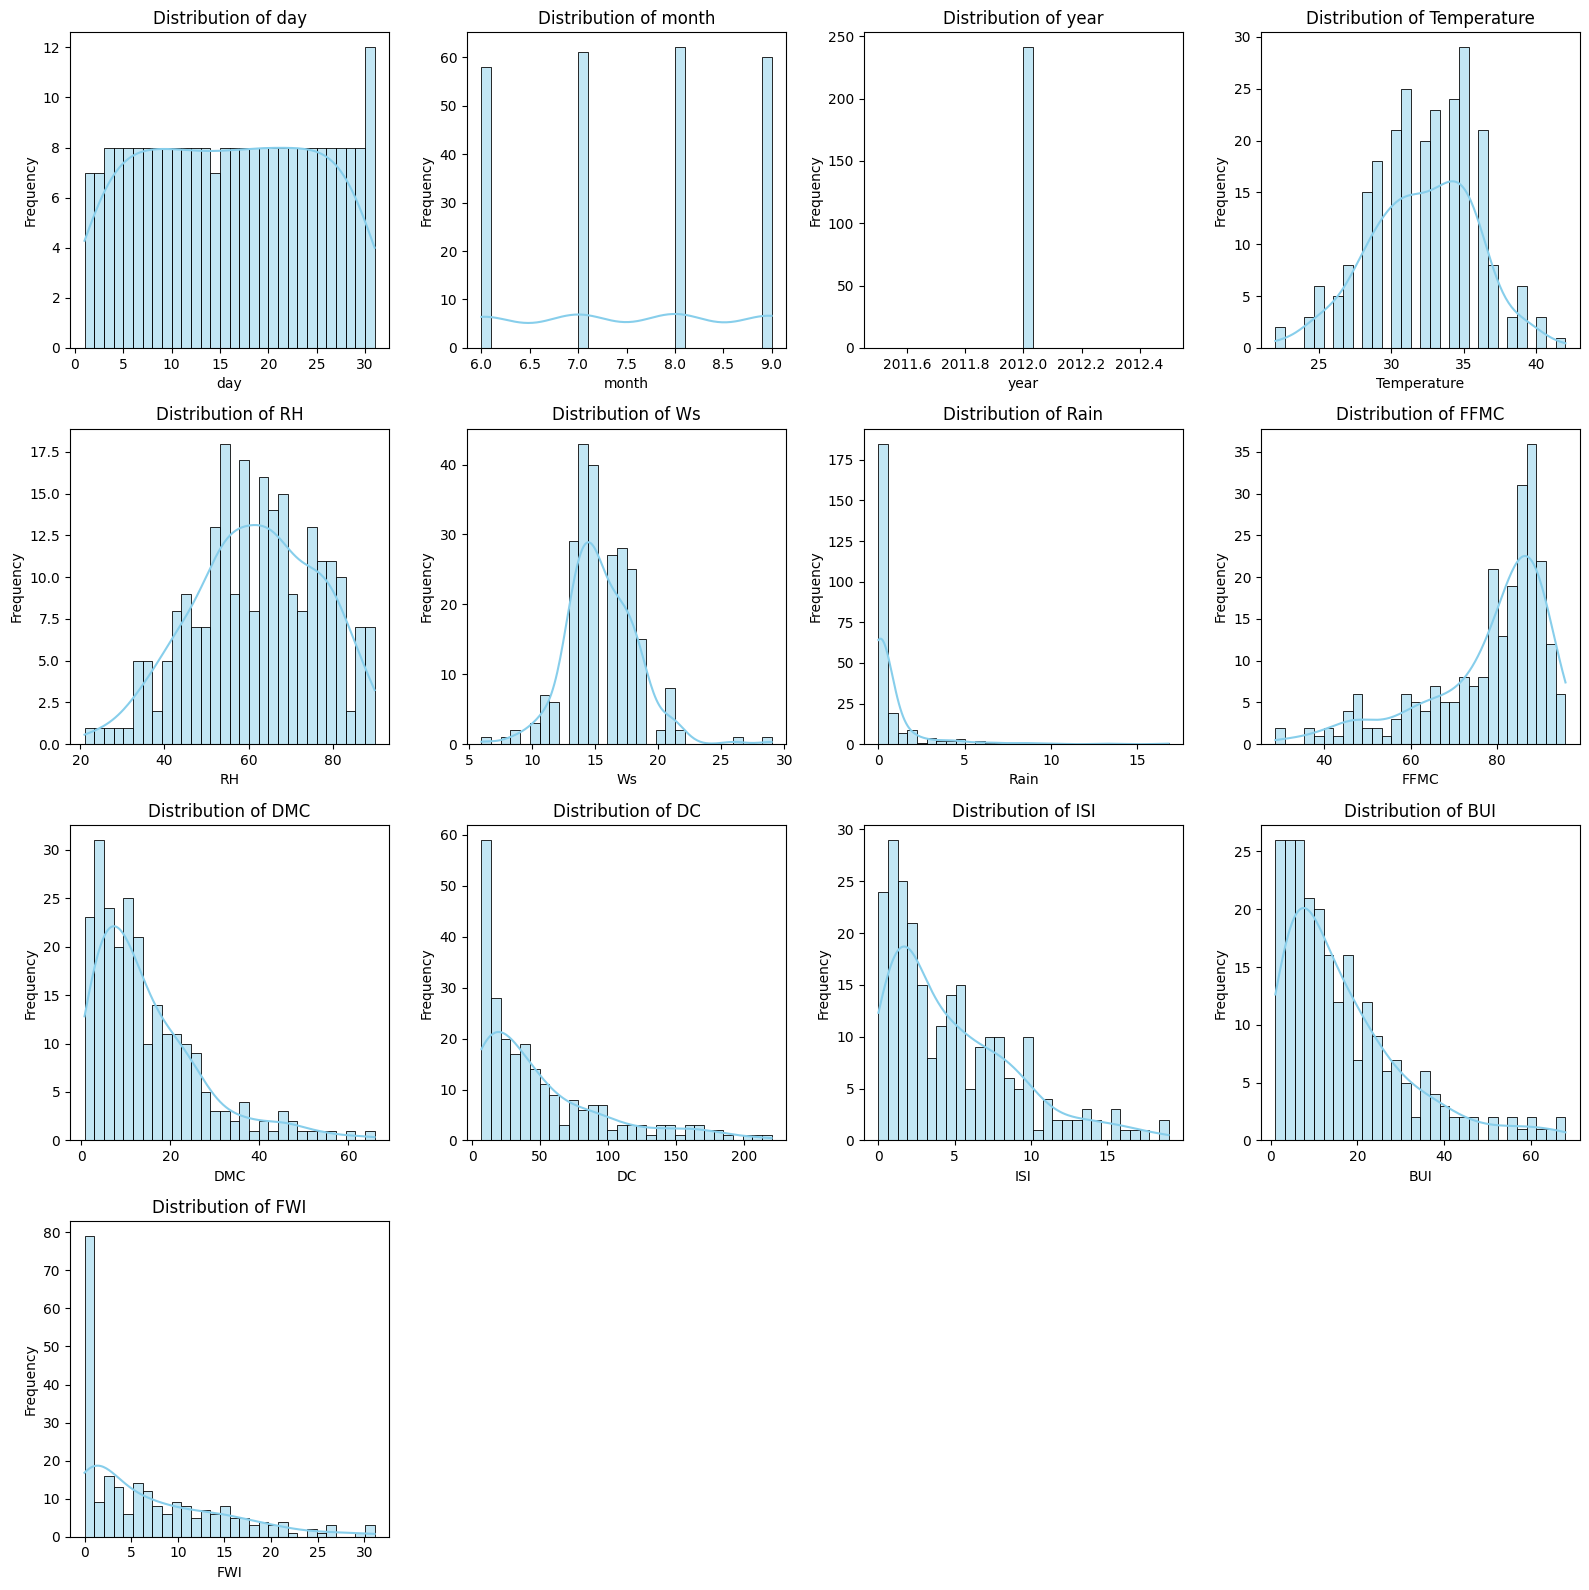

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numeric columns
numeric_cols = [
    'day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain',
    'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI'
]

# Define subplot grid
n_cols = 4  # number of columns in subplot grid
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols  # auto calculate rows

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()  # flatten axes for easy iteration

# Plot histograms with KDE
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, bins=30, color='skyblue', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove unused subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


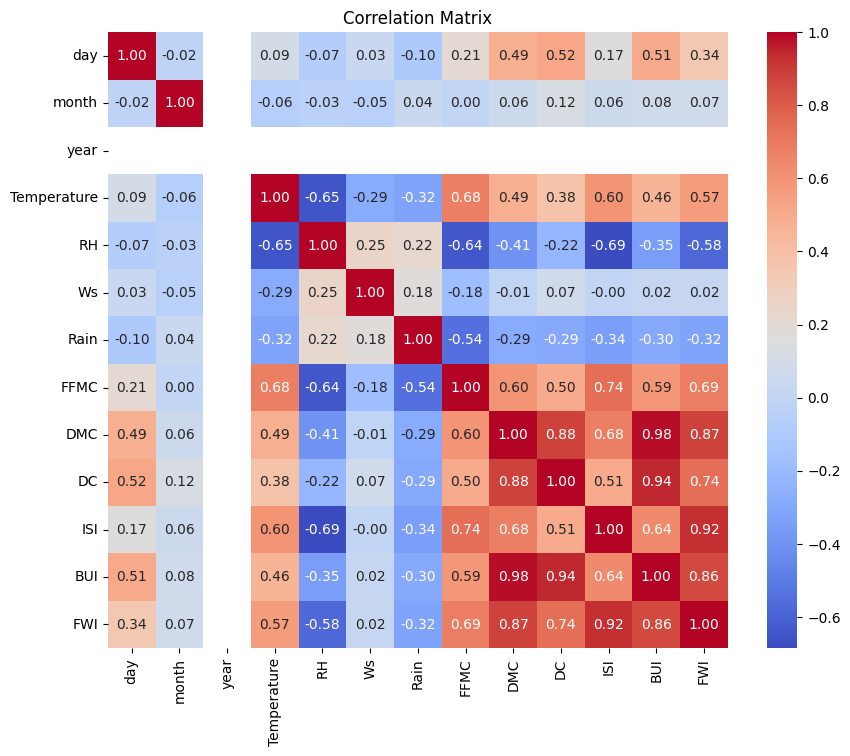

In [29]:
#A correlation matrix shows how strongly pairs of numerical features are related (values range from -1 to +1).
#+1 → strong positive relationship.
#-1 → strong negative relationship
#0 → weak/no linear relationship(features which have 0 corelation need to be eliminated)

# Compute correlation matrix for numeric columns
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


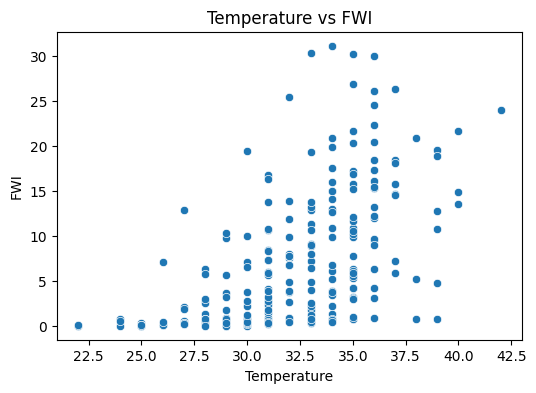

In [30]:
#scatter plot for temp vs fwi
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Temperature'], y=df['FWI'])
plt.title("Temperature vs FWI")
plt.xlabel("Temperature")
plt.ylabel("FWI")
plt.show()


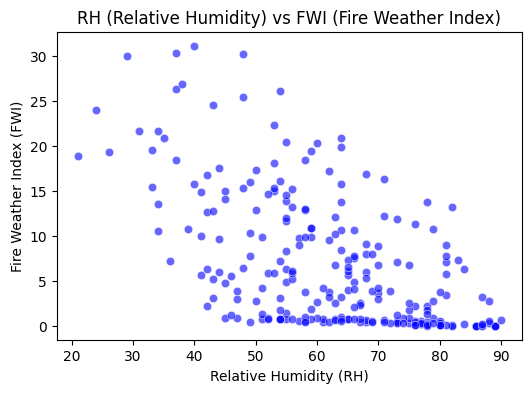

In [31]:


plt.figure(figsize=(6,4))
sns.scatterplot(x=df['RH'], y=df['FWI'], alpha=0.6, color="blue", edgecolor="w")
plt.title("RH (Relative Humidity) vs FWI (Fire Weather Index)")
plt.xlabel("Relative Humidity (RH)")
plt.ylabel("Fire Weather Index (FWI)")
plt.show()


In [32]:
features = ['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'region']  # match your exact column names
features.append('FWI')


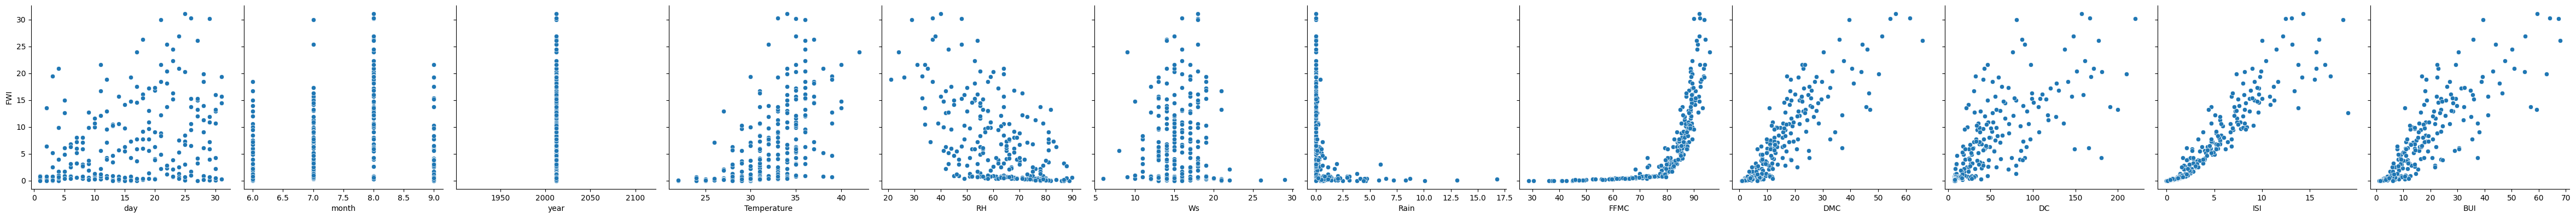

In [33]:

#  Select numeric features only (excluding FWI) ---
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'FWI' not in numeric_features:
    raise ValueError("Target column 'FWI' not found among numeric columns!")

features_to_plot = [col for col in numeric_features if col != 'FWI']

#  Pair plot against FWI ---
sns.pairplot(df, y_vars=['FWI'], x_vars=features_to_plot, height=4, kind='scatter')
plt.show()


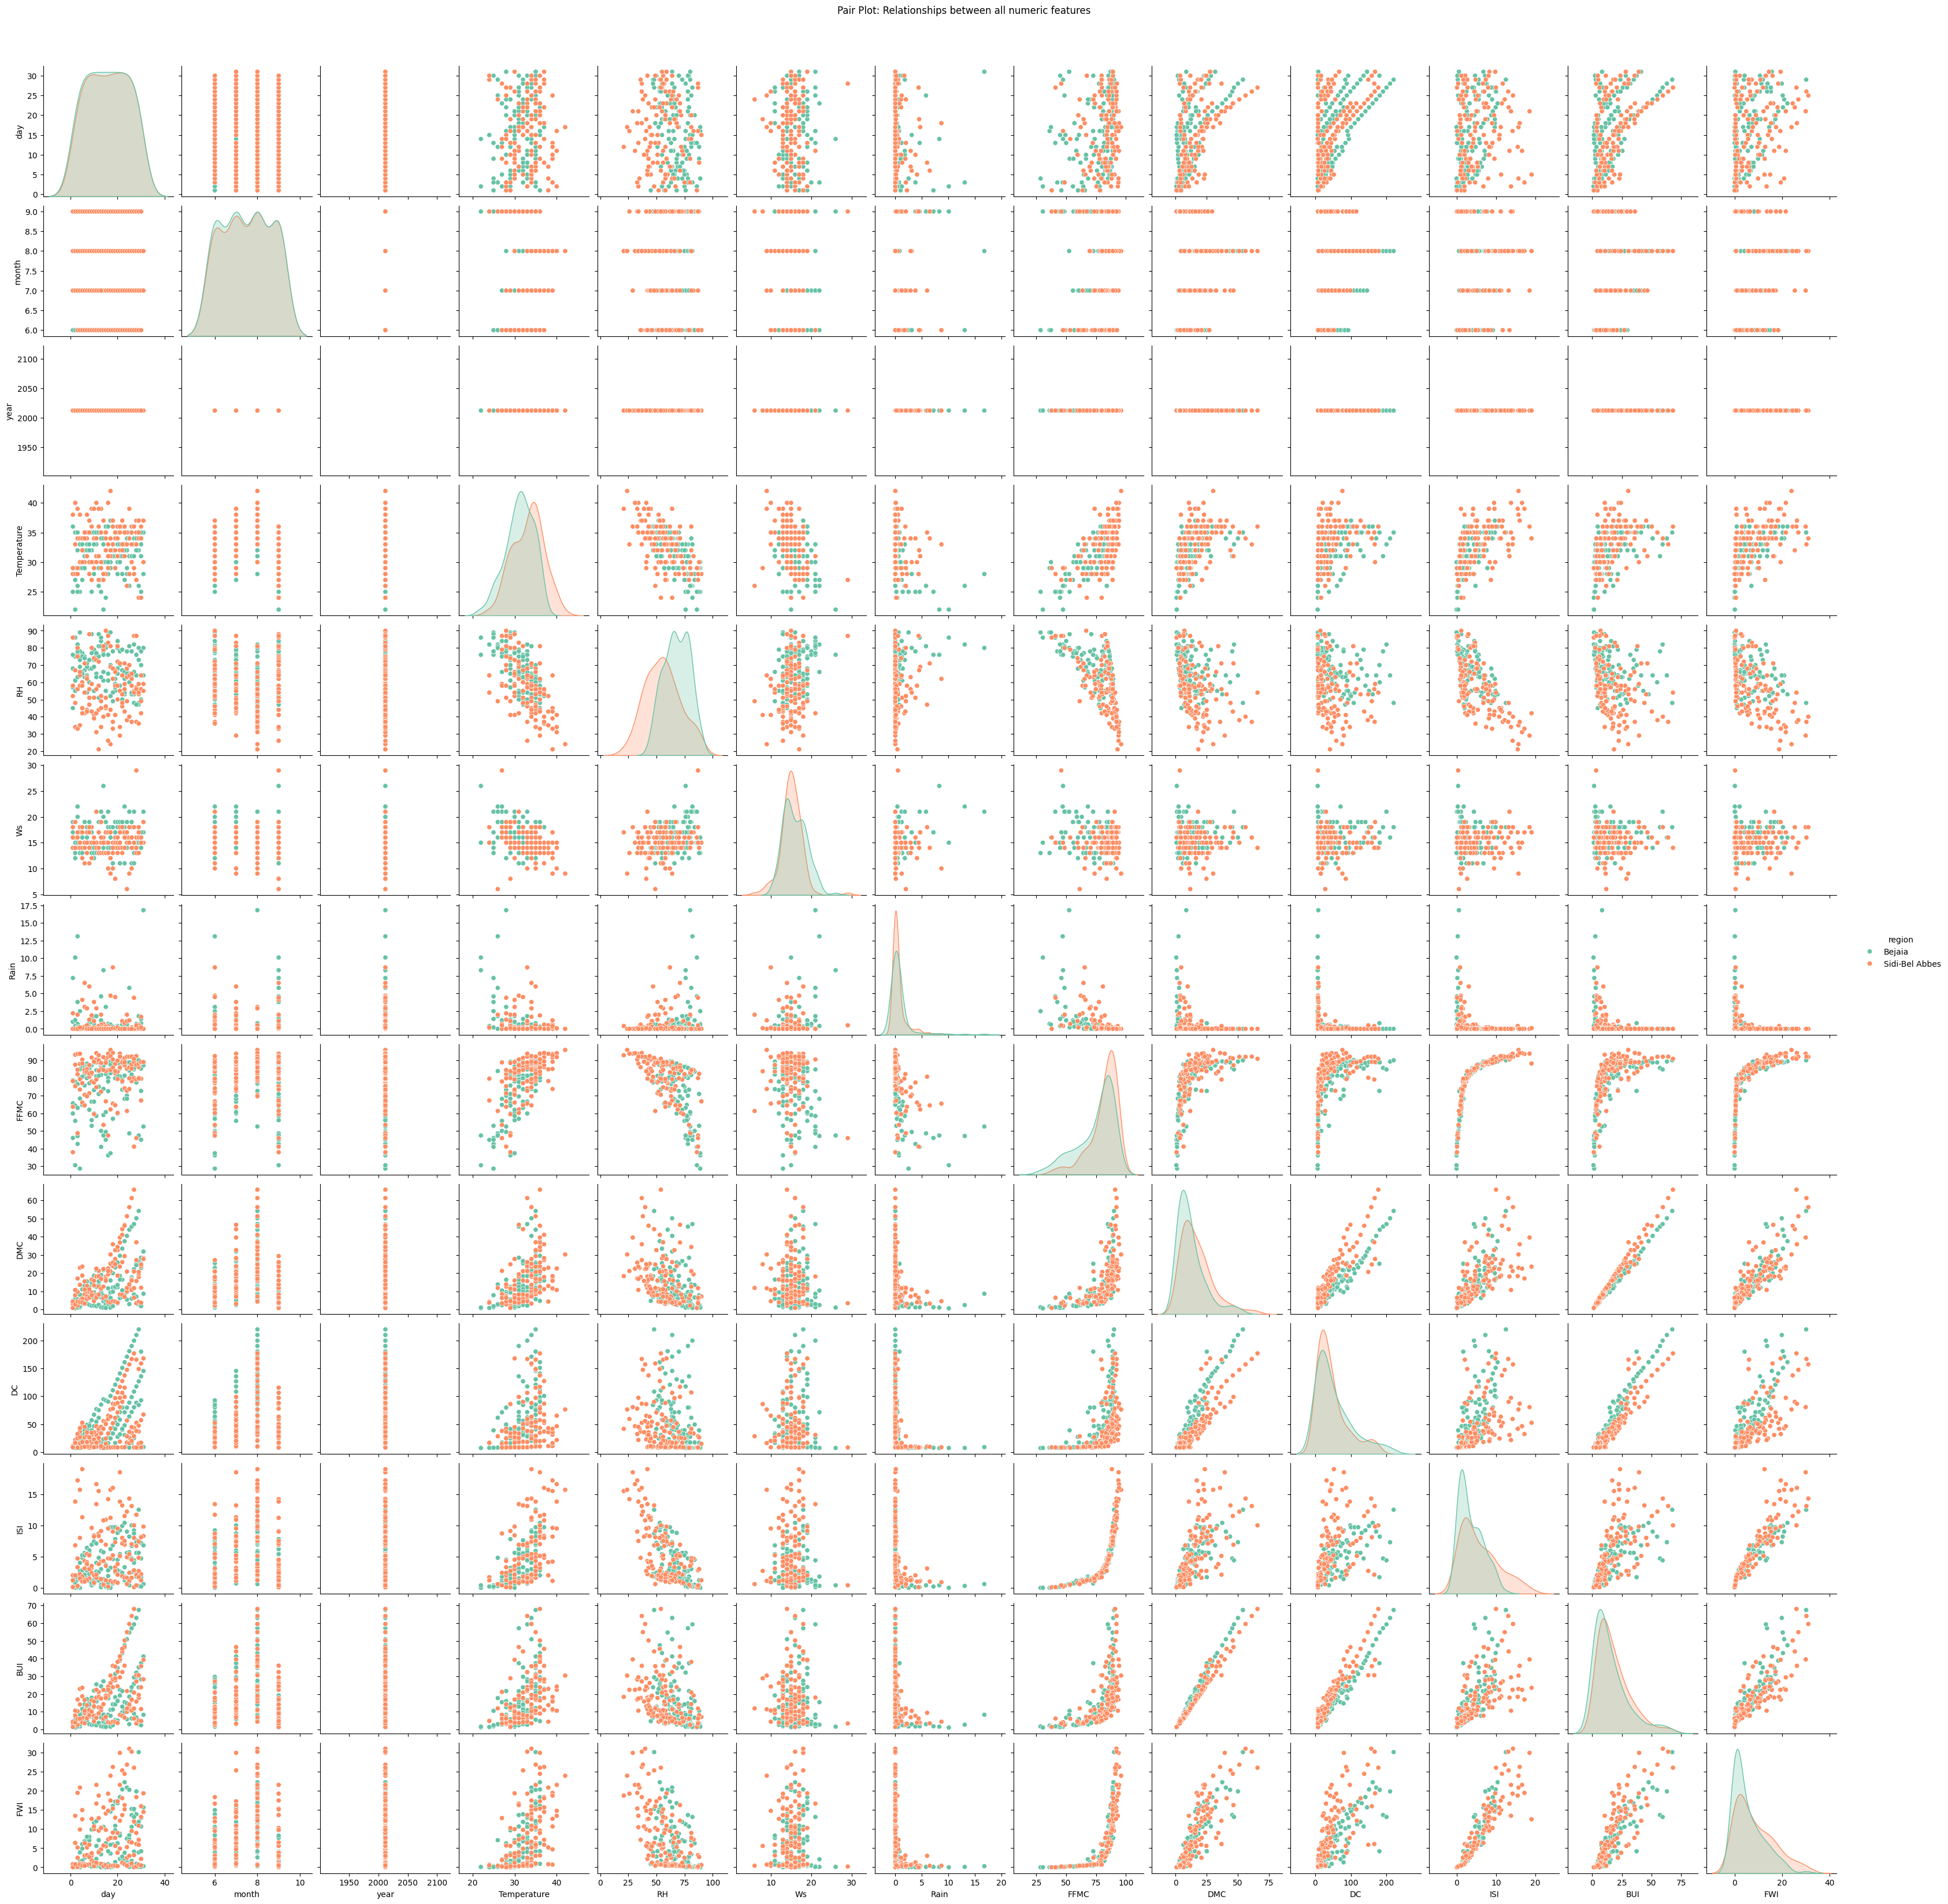

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric features
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Create pair plot with coloring by region
sns.pairplot(df[numeric_features + ['region']], hue='region', palette='Set2', height=2.5)
plt.suptitle("Pair Plot: Relationships between all numeric features", y=1.02)
plt.show()


In [35]:
df['region'].unique()


array(['Bejaia', 'Sidi-Bel Abbes'], dtype=object)

In [36]:
# Example: Bejaia = 0, Sidi Bel-Abbes = 1
df["region"] = df["region"].map({"Bejaia": 0, "Sidi Bel-Abbes": 1})#mapping


In [37]:
# First, imported LabelEncoder
from sklearn.preprocessing import LabelEncoder

# Then created the encoder and apply it
le = LabelEncoder()
df["region"] = le.fit_transform(df["region"])


In [38]:
df.to_csv("cleaned_fwi_dataset.csv", index=False)
print("Cleaned dataset saved successfully!")


Cleaned dataset saved successfully!


Module 3: Feature Engineering and Scaling

In [39]:
corr_matrix = df.corr()
corr_with_fwi = corr_matrix['FWI'].sort_values(ascending=False)
print(corr_with_fwi)


FWI            1.000000
ISI            0.922326
DMC            0.874943
BUI            0.856918
DC             0.737783
FFMC           0.688538
Temperature    0.566649
day            0.343377
region         0.206362
month          0.073135
Ws             0.024420
Rain          -0.321227
RH            -0.578951
year                NaN
Name: FWI, dtype: float64


In [40]:
# Compute correlation with target
corr_with_target = df.corr()['FWI']

# Set a threshold for "near zero" correlation
threshold = 0.4

# Select features with absolute correlation above threshold or explicitly keeping 'Ws' &'rain'
key_features = corr_with_target[
    (abs(corr_with_target) > threshold) | (corr_with_target.index == 'Ws')| (corr_with_target.index == 'Rain')
].index.tolist() 
 
print("Selected features based on correlation:", key_features)


Selected features based on correlation: ['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI']


In [41]:
# Remove FWI from selected features
key_features = [f for f in key_features if f != 'FWI']

X = df[key_features]
y = df['FWI']

print("Shape of input features (X):", X.shape)
print("Shape of target variable (y):", y.shape)


Shape of input features (X): (241, 9)
Shape of target variable (y): (241,)


In [42]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Apply scaler to numerical features only
numerical_features = df[key_features].select_dtypes(include=['int64', 'float64']).columns

df[numerical_features] = scaler.fit_transform(df[numerical_features])

# Check scaled features
print(df.head())


   day  month  year  Temperature        RH        Ws      Rain      FFMC  \
0    1      6  2012    -0.870334 -0.334342  0.885082 -0.375563 -0.864898   
1    2      6  2012    -0.870334 -0.064630 -0.898403  0.275593 -0.956159   
2    3      6  2012    -1.696123  1.351355  2.311870  6.186079 -2.170635   
3    4      6  2012    -1.971386  1.823351 -0.898403  0.876659 -3.469351   
4    5      6  2012    -1.420860  1.014216  0.171688 -0.375563 -0.928079   

        DMC        DC       ISI       BUI  FWI  region  
0 -0.920082 -0.885766 -0.838671 -0.943936  0.5       0  
1 -0.863491 -0.885766 -0.911038 -0.908729  0.4       0  
2 -0.992842 -0.896267 -1.079893 -0.993227  0.1       0  
3 -1.089855 -0.900468 -1.152260 -1.063641  0.0       0  
4 -0.952420 -0.747151 -0.862793 -0.908729  0.5       0  


In [43]:
from sklearn.model_selection import train_test_split

# Split input features (X) and target variable (y)
X = df.drop('FWI', axis=1)
y = df['FWI']

# Separating into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [44]:
import pickle

# Save the fitted scaler
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

print("Scaler saved as 'scaler.pkl'")


Scaler saved as 'scaler.pkl'


In [45]:
from sklearn.preprocessing import StandardScaler
from joblib import dump

# Assuming you have scaler fitted
dump(scaler, 'scaler.joblib')


['scaler.joblib']

Module 4: Model Training using Ridge Regression

In [46]:
from sklearn.linear_model import Ridge

# Initialize and train the Ridge Regression model
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [47]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid for alpha tuning
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(Ridge(), param_grid, cv=5)
grid_search.fit(X_train, y_train)

best_alpha = grid_search.best_params_['alpha']
best_model = grid_search.best_estimator_
print("Best alpha:", best_alpha)
print("Best Ridge model:", best_model)


Best alpha: 10
Best Ridge model: Ridge(alpha=10)


In [48]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Predictions
y_train_pred = ridge_model.predict(X_train)               #Metrics such as R² Score, Mean Absolute Error (MAE), and Mean Squared Error (MSE) were calculated to measure prediction accuracy and generalization.
y_test_pred = ridge_model.predict(X_test)

# Evaluation metrics                                     #This evaluation ensured that the model performed well on unseen data and was not overfitting to the training set.
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training R²:", train_r2)
print("Testing R²:", test_r2)


Training R²: 0.9716601627949089
Testing R²: 0.9877420400985277


In [49]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from math import sqrt

# Split: 60% train, 20% validation, 20% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Train Ridge Regression model
ridge_model = Ridge(alpha=10)
ridge_model.fit(X_train, y_train)

# Predictions
y_train_pred = ridge_model.predict(X_train)
y_val_pred = ridge_model.predict(X_val)
y_test_pred = ridge_model.predict(X_test)

# Evaluation metrics
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = sqrt(mean_squared_error(y_val, y_val_pred))
test_rmse = sqrt(mean_squared_error(y_test, y_test_pred))

train_mae = mean_absolute_error(y_train, y_train_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

# Display results
print("Training R²:", train_r2)
print("Validation R²:", val_r2)
print("Testing R²:", test_r2)
print("Training RMSE:", train_rmse)
print("Validation RMSE:", val_rmse)
print("Testing RMSE:", test_rmse)
print("Training MAE:", train_mae)
print("Validation MAE:", val_mae)
print("Testing MAE:", test_mae)


Training R²: 0.9627798656933819
Validation R²: 0.9792019095285874
Testing R²: 0.9597204516990787
Training RMSE: 1.4474212620325024
Validation RMSE: 1.205513230323478
Testing RMSE: 1.217497761146998
Training MAE: 0.9265042563187207
Validation MAE: 0.8827493991950455
Testing MAE: 0.8697370298004713


In [50]:
from math import sqrt

# Evaluate performance
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = sqrt(mean_squared_error(y_test, y_test_pred))

print("Training R²:", train_r2)
print("Validation R²:", test_r2)
print("Training RMSE:", train_rmse)
print("Validation RMSE:", test_rmse)


Training R²: 0.9627798656933819
Validation R²: 0.9597204516990787
Training RMSE: 1.4474212620325024
Validation RMSE: 1.217497761146998


In [51]:
import pickle

# Save the trained Ridge model
with open('ridge.pkl', 'wb') as file:
    pickle.dump(best_model, file)

print("Model saved as 'ridge.pkl'")


Model saved as 'ridge.pkl'


In [52]:
model_info = {
    "Model Name": "Ridge Regression",
    "Alpha Value": 10,
    "Train R²": train_r2,
    "Validation R²": test_r2,
    "Train RMSE": train_rmse,
    "Validation RMSE": test_rmse,
    "Data Split": "80% Train - 20% Test",
    "Scaler Used": "StandardScaler",
    "Random State": 42
}

# Save model information for reference
import json
with open("ridge_model_details.json", "w") as f:
    json.dump(model_info, f, indent=4)

print("Training details documented in ridge_model_details.json")


Training details documented in ridge_model_details.json


In [53]:
from sklearn.model_selection import train_test_split #Lasso Regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_squared_error

# Features and target
X = df.drop('FWI', axis=1)
y = df['FWI']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Lasso Regression
model = Lasso(alpha=0.1)
model.fit(X_train, y_train)

# Predictions and evaluation
y_pred = model.predict(X_test)
print("R² Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


R² Score: 0.9856137846727144
MSE: 0.6956298935341598


In [54]:
from sklearn.linear_model import ElasticNet  #ElasticNet Reg

model = ElasticNet(alpha=0.1, l1_ratio=0.5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))



R² Score: 0.973843847362763


In [55]:
from sklearn.tree import DecisionTreeRegressor #DecisionTreeReg

model = DecisionTreeRegressor(max_depth=5, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))


R² Score: 0.9605502533789714


In [63]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))


R² Score: 0.9827628640320697


In [64]:
from sklearn.model_selection import train_test_split #as i got r2 max for randomforest,Iam checking for training and testing of r2 and rmse
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Split: 60% train, 20% validation, 20% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Train Random Forest model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_train_pred = rf_model.predict(X_train)
y_val_pred = rf_model.predict(X_val)
y_test_pred = rf_model.predict(X_test)

# Evaluation metrics
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
test_r2 = r2_score(y_test, y_test_pred)


train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Display results
print("Training R²:", train_r2)
print("Validation R²:", val_r2)
print("Testing R²:", test_r2)

print("Training RMSE:", train_rmse)
print("Validation RMSE:", val_rmse)
print("Testing RMSE:", test_rmse)


Training R²: 0.9941332463542824
Validation R²: 0.9783939580913303
Testing R²: 0.9827628640320697
Training RMSE: 0.5746519780122
Validation RMSE: 1.228705653658897
Testing RMSE: 0.7964498395622767


In [58]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))


R² Score: 0.9751989737207426


In [59]:
# Step 1: Import libraries
import pickle
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

# Step 2: Split data (only if not done yet)
# Make sure X and y are already defined as your features and target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train Ridge model
ridge = Ridge(alpha=10)
ridge.fit(X_train, y_train)

# Step 4: Save trained model
with open('ridge.pkl', 'wb') as file:
    pickle.dump(ridge, file)

print("✅ Model trained and saved successfully as ridge.pkl")


✅ Model trained and saved successfully as ridge.pkl


Module 5: Evaluation and Optimization


In [60]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from math import sqrt

# Split: 60% train, 20% validation, 20% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Train Ridge Regression model
ridge_model = Ridge(alpha=10)
ridge_model.fit(X_train, y_train)

# Predictions
y_train_pred = ridge_model.predict(X_train)
y_val_pred = ridge_model.predict(X_val)
y_test_pred = ridge_model.predict(X_test)

# Evaluation metrics
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = sqrt(mean_squared_error(y_val, y_val_pred))
test_rmse = sqrt(mean_squared_error(y_test, y_test_pred))

train_mae = mean_absolute_error(y_train, y_train_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

# Display results
print("Training R²:", train_r2)
print("Validation R²:", val_r2)
print("Testing R²:", test_r2)
print("Training RMSE:", train_rmse)
print("Validation RMSE:", val_rmse)
print("Testing RMSE:", test_rmse)
print("Training MAE:", train_mae)
print("Validation MAE:", val_mae)
print("Testing MAE:", test_mae)


Training R²: 0.9627798656933819
Validation R²: 0.9792019095285874
Testing R²: 0.9597204516990787
Training RMSE: 1.4474212620325024
Validation RMSE: 1.205513230323478
Testing RMSE: 1.217497761146998
Training MAE: 0.9265042563187207
Validation MAE: 0.8827493991950455
Testing MAE: 0.8697370298004713


R² (Coefficient of Determination) measures how much of the target variable’s variance is explained by the model.
R² = 1 → perfect prediction
R² = 0 → model predicts no better than mean
Negative R² → model performs worse than baseline

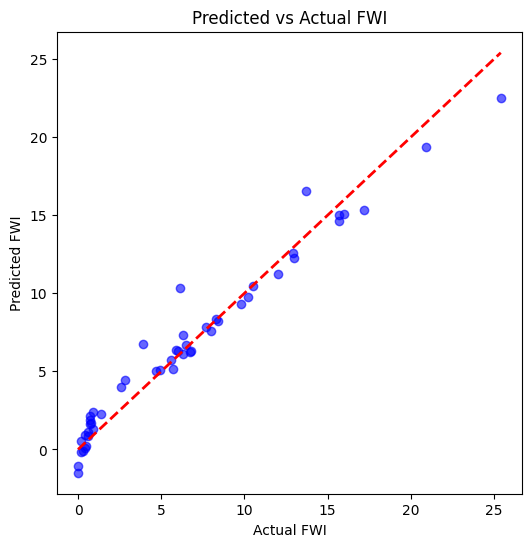

In [61]:
#  Plot Predicted vs Actual values
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual FWI')
plt.ylabel('Predicted FWI')
plt.title('Predicted vs Actual FWI')
plt.show()


In [62]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import numpy as np

# List of alpha values to try
alpha_list = [0.001, 0.01, 0.1,0.5, 1, 10, 100]

best_alpha = None
lowest_rmse = np.inf

for alpha in alpha_list:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"Alpha: {alpha}, RMSE: {rmse:.4f}")
    
    if rmse < lowest_rmse:
        lowest_rmse = rmse
        best_alpha = alpha

print(f"\nBest alpha: {best_alpha}")
print(f"Lowest RMSE on validation set: {lowest_rmse:.4f}")

# Retrain final model with best alpha
final_model = Ridge(alpha=best_alpha)
final_model.fit(X_train, y_train)
print("Final model retrained with optimal alpha.")


Alpha: 0.001, RMSE: 0.9621
Alpha: 0.01, RMSE: 0.9407


Alpha: 0.1, RMSE: 0.8661
Alpha: 0.5, RMSE: 0.9010
Alpha: 1, RMSE: 0.9387
Alpha: 10, RMSE: 1.2175
Alpha: 100, RMSE: 2.2588

Best alpha: 0.1
Lowest RMSE on validation set: 0.8661
Final model retrained with optimal alpha.


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import numpy as np

# Different alpha values to test
alpha_values = [0.001, 0.01, 0.1, 0.5, 1, 10, 100]

best_alpha = None
lowest_rmse = float('inf')

for alpha in alpha_values:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    
    y_val_pred = model.predict(X_val)          # Predict on validation data

    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    print(f'Alpha: {alpha}, RMSE: {rmse:.4f}')
    
    # Keep track of the best alpha
    if rmse < lowest_rmse:
        lowest_rmse = rmse
        best_alpha = alpha

print("\nBest alpha:", best_alpha)
print("Lowest RMSE on validation set:", lowest_rmse)


Alpha: 0.001, RMSE: 0.9672
Alpha: 0.01, RMSE: 0.9613
Alpha: 0.1, RMSE: 0.9305
Alpha: 0.5, RMSE: 0.9129
Alpha: 1, RMSE: 0.9219
Alpha: 10, RMSE: 1.2055
Alpha: 100, RMSE: 2.5396

Best alpha: 0.5
Lowest RMSE on validation set: 0.9129074302464683


Module 6: Deployment via Flask App